## Adding an Analytic Column

### Purpose
An "analytic column" is a derived feature added to your dataset to capture information not directly available from the raw columns. These columns help models, visualizations, and human analysts by summarizing trends, normalizing scales, or encoding domain-specific knowledge (for example, returns, moving averages, volatility, or trend signals).

### Common Analytic Columns
- **Daily Return**: Percentage change from the previous close.
- **Moving Averages**: Simple or exponential averages over a rolling window.
- **Volatility**: Rolling standard deviation of returns.
- **Trend Signals**: Indicators based on thresholds or comparisons (e.g., price vs. moving average).

### Example Code
```python
# Example: Adding daily return and moving average columns
df['daily_return'] = df['Close'].pct_change()
df['ma_10'] = df['Close'].rolling(window=10, min_periods=1).mean()
```

### Best Practices
- Handle missing values appropriately (e.g., drop or fill NaNs).
- Avoid look-ahead bias by using only past data for calculations.
- Choose meaningful window sizes for rolling calculations.

# Stock market trend prediction

### This project focuses on analyzing Tesla’s stock price time series to detect and forecast market trends (bullish, bearish, or neutral). It begins with traditional statistical and technical indicator methods, then progressively integrates advanced machine learning and deep learning algorithms to improve the accuracy and responsiveness of trend detection. The outcome is a comparative study and prototype capable of automatically identifying the current trend and predicting potential reversals.

By Thomas Jin, Thibault Gauthé, Yijia Zhang

In [18]:
import pandas as pd
import ta
import seaborn as sns
import numpy as np
from math import ceil
import matplotlib.pyplot as plt


In [19]:
data = pd.read_csv('Tesla_Stock_Data.csv')
data.head()

,Date,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


### Nettoyage du dataset

In [20]:
data.describe()

,Close,High,Low,Open,Volume
count,3843.000000,3843.000000,3843.000000,3843.000000,3.843000e+03
mean,93.887965,95.992401,91.689924,93.911160,9.699445e+07
std,118.694016,121.435014,115.877610,118.784407,7.621392e+07
min,1.053333,1.108667,0.998667,1.076000,1.777500e+06
25%,12.691667,12.888667,12.409000,12.613667,5.086650e+07
50%,19.454000,19.888000,19.115999,19.483334,8.339850e+07
75%,200.739998,204.591667,195.213333,200.466667,1.222820e+08
max,479.859985,488.540009,457.510010,475.899994,9.140820e+08


In [21]:
data.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

### Dataset is already a cleaned one...

### Add analytic column

In [22]:
# Rendement journalier
data["Return_1d"] = data["Close"].pct_change()
# Moyennes mobiles
data["MA10"] = data["Close"].rolling(10).mean()
data["MA50"] = data["Close"].rolling(50).mean()
data["MA200"] = data["Close"].rolling(200).mean()
# Volatilité glissante
data["Volatility_20d"] = data["Return_1d"].rolling(20).std()
# RSI
data["RSI_14"] = ta.momentum.rsi(data["Close"], window=14)
# MACD + signal
macd = ta.trend.MACD(data["Close"])
data["MACD"] = macd.macd()
data["Signal"] = macd.macd_signal()

In [23]:
data.head()

,Date,Close,High,Low,Open,Volume,Return_1d,MA10,MA50,MA200,Volatility_20d,RSI_14,MACD,Signal
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,-0.002511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,-0.078473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,-0.125683,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,-0.160937,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# 1 if bullish day, 0 if bearish day
data["Trend"] = (data["Close"].shift(-1) > data["Close"]).astype(int)
data.head()

,Date,Close,High,Low,Open,Volume,Return_1d,MA10,MA50,MA200,Volatility_20d,RSI_14,MACD,Signal,Trend
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500,-0.002511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000,-0.078473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000,-0.125683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500,-0.160937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


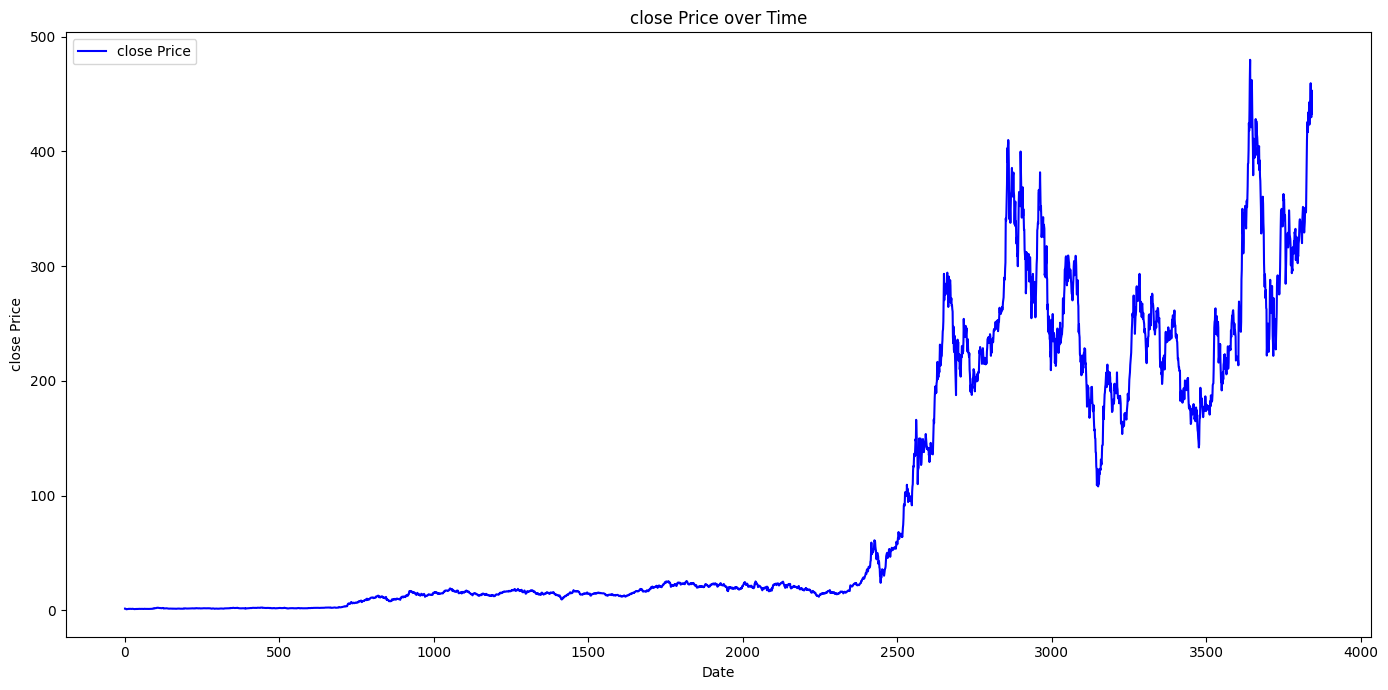

In [25]:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close'], label='close Price', color='blue')
plt.xlabel('Date')
plt.ylabel('close Price')
plt.title('close Price over Time')
plt.legend()
plt.tight_layout()
plt.show()